## Análisis de Componentes Principales
El análisis de componentes principales (PCA) es el proceso mediante el cual se calculan los componentes principales de una matriz de datos con el objeto de realizar una comprensión de los datos. PCA es un enfoque no supervisado, lo que significa que se realiza en un conjunto de variables $X_1, X_2,…, X_d$ sin respuesta asociada $Y$. PCA reduce la dimensionalidad del conjunto de datos, lo que permite explicar la mayor parte de la variabilidad utilizando menos variables. El PCA se usa comúnmente como una primera herramienta de visualización de los datos, para reducir el número de variables y evitar la multicolinealidad, o cuando se tienen demasiados predictores en relación con el número de observaciones.

Sea $X$ una matriz de $n$ datos $d$-dimensionales, con cada componente  de media nula, i.e.

$$X = \begin{pmatrix}
x_{11} &...& x_{1d} \\
&...&\\
x_{n1}&...& x_{nd} \\
\end{pmatrix}
\quad donde \quad \bar{\bf{x}_j}=0, \quad j=1,...,d$$

Buscamos la dirección $w'=(w_1,...,w_d)$ tal que la proyección de $X$ sobre esta dirección maximice la varianza empírica de $Xw$: 

$$\max_w \hat{\sigma}^2(Xw) \quad \text{s. a} \quad \|w\|=1$$

Tenemos que:

$$\hat{\sigma}^2(Xw) =  w'X'Xw  - (\mathbb{E}(Xw))^2= w' \hat{\Sigma} w$$

donde  $\hat{\Sigma}$ es la varianza empírica de $X$:
$$\hat{\Sigma} = X'X = \begin{pmatrix}
\sum_{i=1}^n (x_{i1})^2 &...& \sum_{i=1}^n (x_{i1}x_{id}) \\
&...&\\
\sum_{i=1}^n (x_{id}x_{i1})&...& \sum_{i=1}^n (x_{id})^2  \\
\end{pmatrix}$$

Para maximizar la varianza $\hat{\sigma}^2(Xw)$, construimos el Lagrangiano:

$$L = w' \hat{\Sigma} w + \lambda (w'w-1)$$

La condición de máximo queda:

$$\frac{\partial L}{\partial w} = 2 \hat{\Sigma} w - 2\lambda w = 0 \quad \implies \quad \hat{\Sigma} w = \lambda w$$

Con lo cual $w$ es un vector propio de $\hat{\Sigma}$,  y por lo tanto

$$\hat{\sigma}^2(Xw) = w' \hat{\Sigma} w = w' (\lambda w) = \lambda$$

la dirección de máxima varianza es la dirección asociada al vector propio cuyo valor propio es máximo.
Este procedimiento puede iterarse para obtener la segunda proyección (ortogonal a la primera) de máxima varianza, que será el vector propio correspondiente al segundo mayor valor propio. Y por inducción se pueden obtener las siguientes componentes principales.

Sea
$$ 
    Z_j = w_{j1} X_1 + w_{j2} X_2 + \cdots w_{jd} X_d 
$$ 

la proyección de los datos en la j-ésima componenente principal, se cumple que:

$$ 
    \hat{\sigma}^2(Z_1) \geq \hat{\sigma}^2(Z_2) \geq \cdots \geq \hat{\sigma}^2(Z_d) 
$$ 


Además se cumple  que $S$, la varianza empírica total de los datos $X$ cumple:
$$S \equiv  \sum_{j=1}^d \hat{\sigma}^2(X_j) = \sum_{j=1}^d \hat{\sigma}^2(Z_j)$$



#### Selección del número de componentes principales
La propiedad anterior genera un criterio para decidir el número de componentes principales a considerar en función del porcentaje de varianza explicada. En efecto, la proporción de varianza explicada (PVE) por la m-ésima componente principal se puede calcular como:
$$PVE = \frac{\hat{\sigma}^2(Z_m)}{\sum_{j=1}^d \hat{\sigma}^2(X_j)}= \frac{ \sum_{i=1}^n \sum_{j=1}^d (w_{jm}x_{ij})^2}{ \sum_{j=1}^d \sum_{i=1}^n{x_{ij}}^2}$$

De la demostración previa se tiene que otra manera de calcular el PVE de la m-ésima componente principal es considerando los valores propios:
$$PVE = \frac{\lambda_m}{\sum_{j=1}^d \lambda_j}$$

#### Ejemplo Ilustrativo:
Consideremos el conjunto de datos de "USArrests" que está integrado en R. Este es un conjunto de datos que contiene cuatro variables que representan el número de arrestos por cada 100.000 residentes por asalto, asesinato y violación en cada uno de los cincuenta estados de EE. UU. en el año 1973. Los datos  contienen también  el porcentaje de la población que vive en áreas urbanas, UrbanPop. 

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from IPython.display import Image, display


In [25]:
datos = pd.read_csv("../datasets_simulados/educacion_v5.csv", sep=";")
datos.head(10)

,horas,asistencia,tareas,retrasos,planificacion,nota_final,aprobado
0,4.41,76.87,75.60,0.06,3.53,4.57,True
1,6.78,69.89,86.83,4.12,2.78,4.52,True
2,12.01,164.93,291.28,8.04,10.09,15.14,True
3,2.64,81.53,113.31,3.59,3.55,4.72,True
4,5.39,NaN,77.83,1.46,2.29,4.03,True
5,3.20,65.74,105.50,3.22,3.81,4.19,False
6,2.99,62.02,86.04,-0.66,3.20,4.99,True
7,3.24,91.35,77.82,1.22,2.61,3.64,True
8,3.53,51.06,85.52,2.96,3.25,3.80,True
9,2.42,70.70,94.46,2.92,3.84,3.48,False


### Análisis Exploratorio de Datos

            horas  asistencia      tareas    retrasos  planificacion  \
count  495.000000  495.000000  495.000000  495.000000     495.000000   
mean     4.349010   78.297354   92.906626    2.121879       3.198444   
std      1.992977   20.156216   40.663798    1.751389       1.239070   
min      0.740000   34.820000   51.260000   -1.820000       0.640000   
25%      3.225000   67.235000   76.565000    0.850000       2.530000   
50%      4.080000   74.730000   84.460000    1.970000       3.070000   
75%      4.860000   84.360000   93.380000    3.150000       3.555000   
max     16.120000  187.570000  322.910000   11.020000      10.090000   

       nota_final  
count  495.000000  
mean     4.552162  
std      1.801848  
min      1.680000  
25%      3.660000  
50%      4.230000  
75%      4.925000  
max     15.140000  


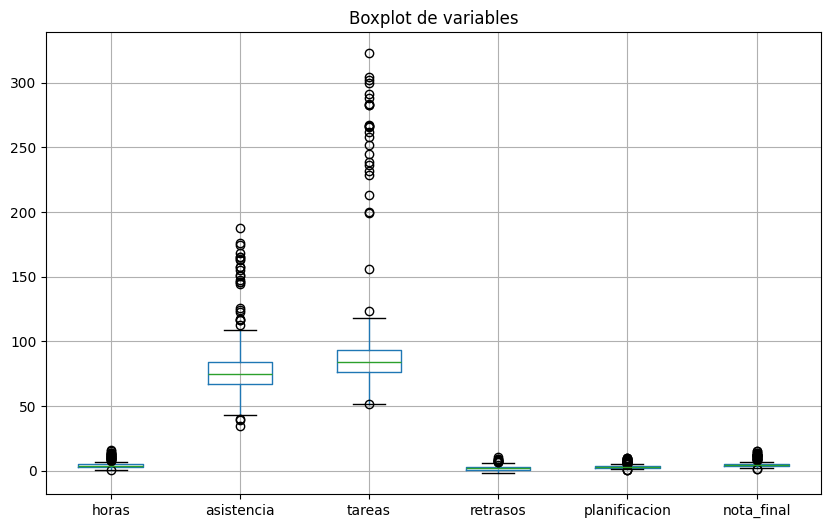

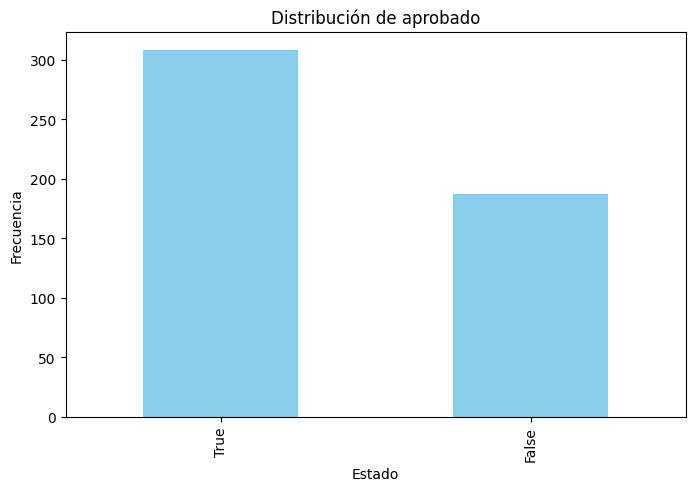

In [27]:
# Resumen de cada variable
print(datos.describe())
# Boxplot de las primeras 6 variables
plt.figure(figsize=(10, 6))
datos.iloc[:, 0:6].boxplot()
plt.title("Boxplot de variables")
plt.show()
# Barplot de la frecuencia de la séptima variable (índice 6)
plt.figure(figsize=(8, 5))
datos.iloc[:, 6].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribución de aprobado")
plt.xlabel("Estado")
plt.ylabel("Frecuencia")
plt.show()

Dimensiones: (477, 5)
            horas  asistencia      tareas    retrasos  planificacion
count  477.000000  477.000000  477.000000  477.000000     477.000000
mean     4.357212   78.539266   92.612453    2.125472       3.207883
std      2.001280   20.203096   40.780612    1.708066       1.252306
min      0.740000   34.820000   51.260000   -1.820000       0.640000
25%      3.240000   67.360000   76.510000    0.860000       2.550000
50%      4.090000   74.870000   84.240000    2.020000       3.080000
75%      4.850000   84.430000   92.870000    3.150000       3.550000
max     16.120000  187.570000  322.910000    8.990000      10.090000


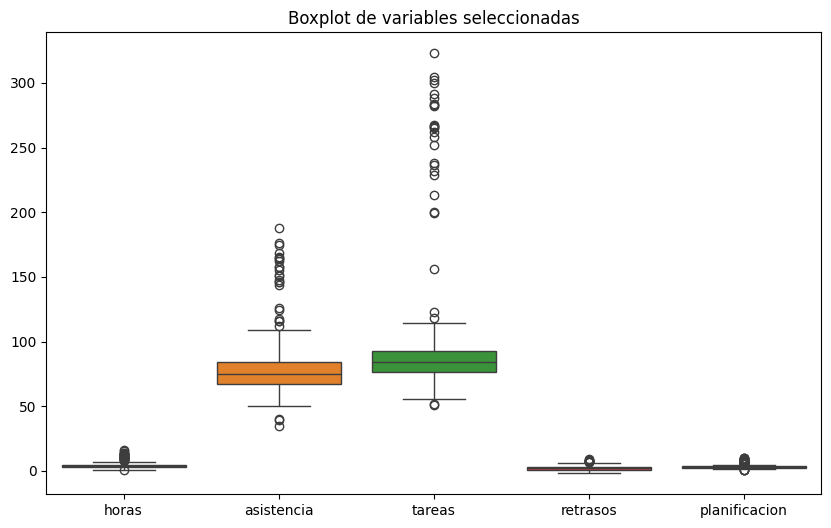

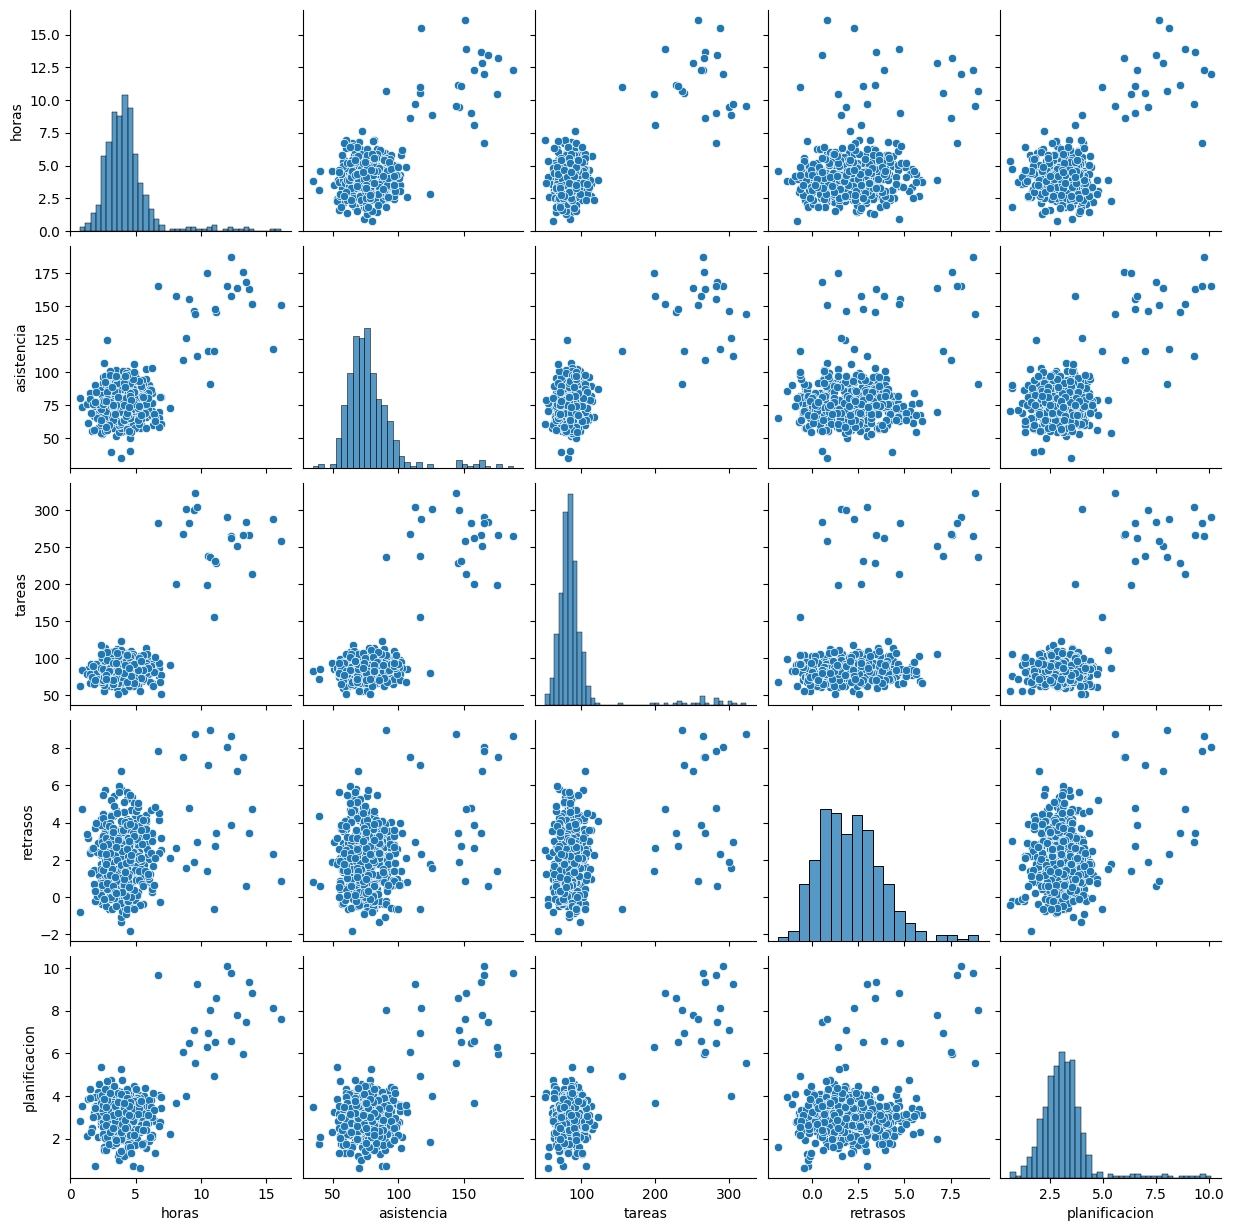

Matriz de correlación:
                  horas  asistencia    tareas  retrasos  planificacion
horas          1.000000    0.628178  0.744915  0.248881       0.599661
asistencia     0.628178    1.000000  0.744944  0.206153       0.585946
tareas         0.744915    0.744944  1.000000  0.336141       0.728063
retrasos       0.248881    0.206153  0.336141  1.000000       0.266693
planificacion  0.599661    0.585946  0.728063  0.266693       1.000000


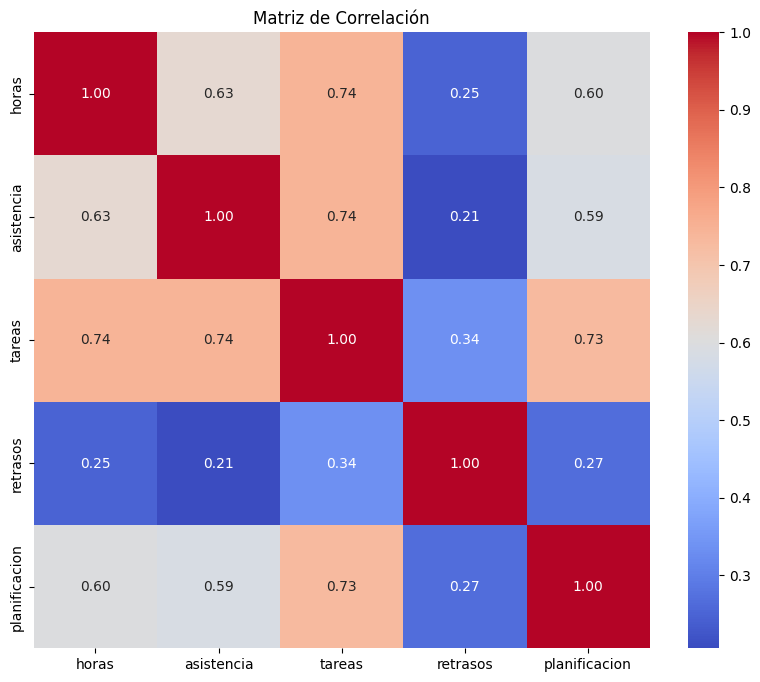

In [28]:
# Seleccionar las primeras 5 columnas y eliminar filas con valores nulos
datos = datos.iloc[:, 0:5].dropna()

# Dimensiones y resumen estadístico
print(f"Dimensiones: {datos.shape}")
print(datos.describe())

# Boxplot de todas las variables
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos)
plt.title("Boxplot de variables seleccionadas")
plt.show()

# Gráfico de dispersión (Matriz de puntos)
sns.pairplot(datos)
plt.show()

# Matriz de correlación
mcor = datos.corr()
print("Matriz de correlación:")
print(mcor)

# Visualización de la matriz de correlación (corrplot)
plt.figure(figsize=(10, 8))
sns.heatmap(mcor, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de Correlación")
plt.show()

In [29]:
varianzas = datos.var()
medias = datos.mean()
print("Varianzas por columna:")
print(varianzas)
print("\nMedias por columna:")
print(medias)

Varianzas por columna:
horas               4.005121
asistencia        408.165081
tareas           1663.058299
retrasos            2.917488
planificacion       1.568270
dtype: float64

Medias por columna:
horas             4.357212
asistencia       78.539266
tareas           92.612453
retrasos          2.125472
planificacion     3.207883
dtype: float64


#### Preparando los datos
Para desarrollar los algoritmos vistos es preferible que cada variable  se centre en cero y que tengan una escala común. Por ejemplo, la varianza de Asalto es 6945, mientras que la varianza de Asesinato es solo 18.97. Los datos de Asalto no son necesariamente más variables, simplemente están en una escala diferente en relación con el Asesinato.

In [31]:
# Escalar los datos (media 0, varianza 1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(datos)
# Convertir de nuevo a DataFrame para mantener los nombres de las columnas
scaled_df = pd.DataFrame(scaled_data, columns=datos.columns)
# Primeras filas del DataFrame escalado
print("Primeras filas de scaled_df:")
print(scaled_df.head())
# Varianza por columna (debería ser aproximadamente 1)
print("\nVarianzas en scaled_df:")
print(scaled_df.var())
# Media por columna (debería ser aproximadamente 0)
print("\nMedias en scaled_df:")
print(scaled_df.mean())

Primeras filas de scaled_df:
      horas  asistencia    tareas  retrasos  planificacion
0  0.026405   -0.082711 -0.417608 -1.210516       0.257489
1  1.211890   -0.428565 -0.141943  1.168938      -0.342034
2  3.827962    4.280603  4.876732  3.466341       5.501326
3 -0.858958    0.148189  0.508067  0.858319       0.273477
4 -0.578843   -0.634195  0.316353  0.641473       0.481312

Varianzas en scaled_df:
horas            1.002101
asistencia       1.002101
tareas           1.002101
retrasos         1.002101
planificacion    1.002101
dtype: float64

Medias en scaled_df:
horas           -3.649538e-16
asistencia      -8.863164e-16
tareas           1.638568e-16
retrasos         1.154446e-16
planificacion    7.448037e-18
dtype: float64


In [ ]:
# escalando los datos
scaled_df <- apply(datos, 2, scale)
head(scaled_df)
apply(scaled_df, 2, var)

apply(scaled_df, 2, mean)

horas,asistencia,tareas,retrasos,planificacion
0.02637725,-0.08262428,-0.4171701,-1.2092461,0.257219421
1.21061949,-0.42811588,-0.1417942,1.1677117,-0.341675781
3.82394731,4.27611364,4.8716176,3.4627055,5.495556123
-0.85805683,0.14803344,0.5075340,0.8574192,0.273189960
-0.57823588,-0.63352995,0.3160214,0.6407999,0.480806963
-0.68316873,-0.81766014,-0.1611661,-1.6307755,-0.006294468


horas    asistencia        tareas      retrasos planificacion 
            1             1             1             1             1

horas    asistencia        tareas      retrasos planificacion 
 7.496805e-17 -1.968855e-16  1.660731e-16  1.146394e-16  1.284349e-17

Resumen de scaled_df:
              horas    asistencia        tareas      retrasos  planificacion
count  4.770000e+02  4.770000e+02  4.770000e+02  4.770000e+02   4.770000e+02
mean  -3.649538e-16 -8.863164e-16  1.638568e-16  1.154446e-16   7.448037e-18
std    1.001050e+00  1.001050e+00  1.001050e+00  1.001050e+00   1.001050e+00
min   -1.809347e+00 -2.166260e+00 -1.015087e+00 -2.312331e+00  -2.052676e+00
25%   -5.588348e-01 -5.539252e-01 -3.952701e-01 -7.416578e-01  -5.258885e-01
50%   -1.336606e-01 -1.818097e-01 -2.055203e-01 -6.181403e-02  -1.022249e-01
75%    2.464951e-01  2.918819e-01  6.322062e-03  6.004476e-01   2.734768e-01
max    5.883804e+00  5.402400e+00  5.653160e+00  4.023110e+00   5.501326e+00


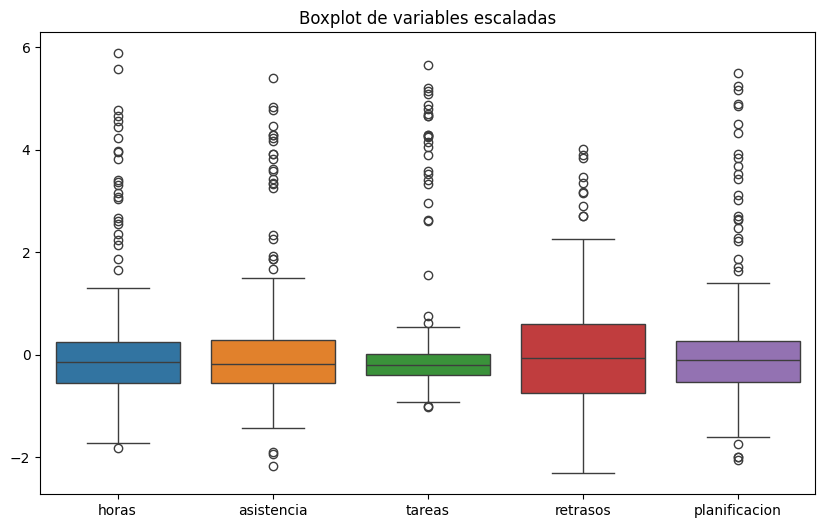

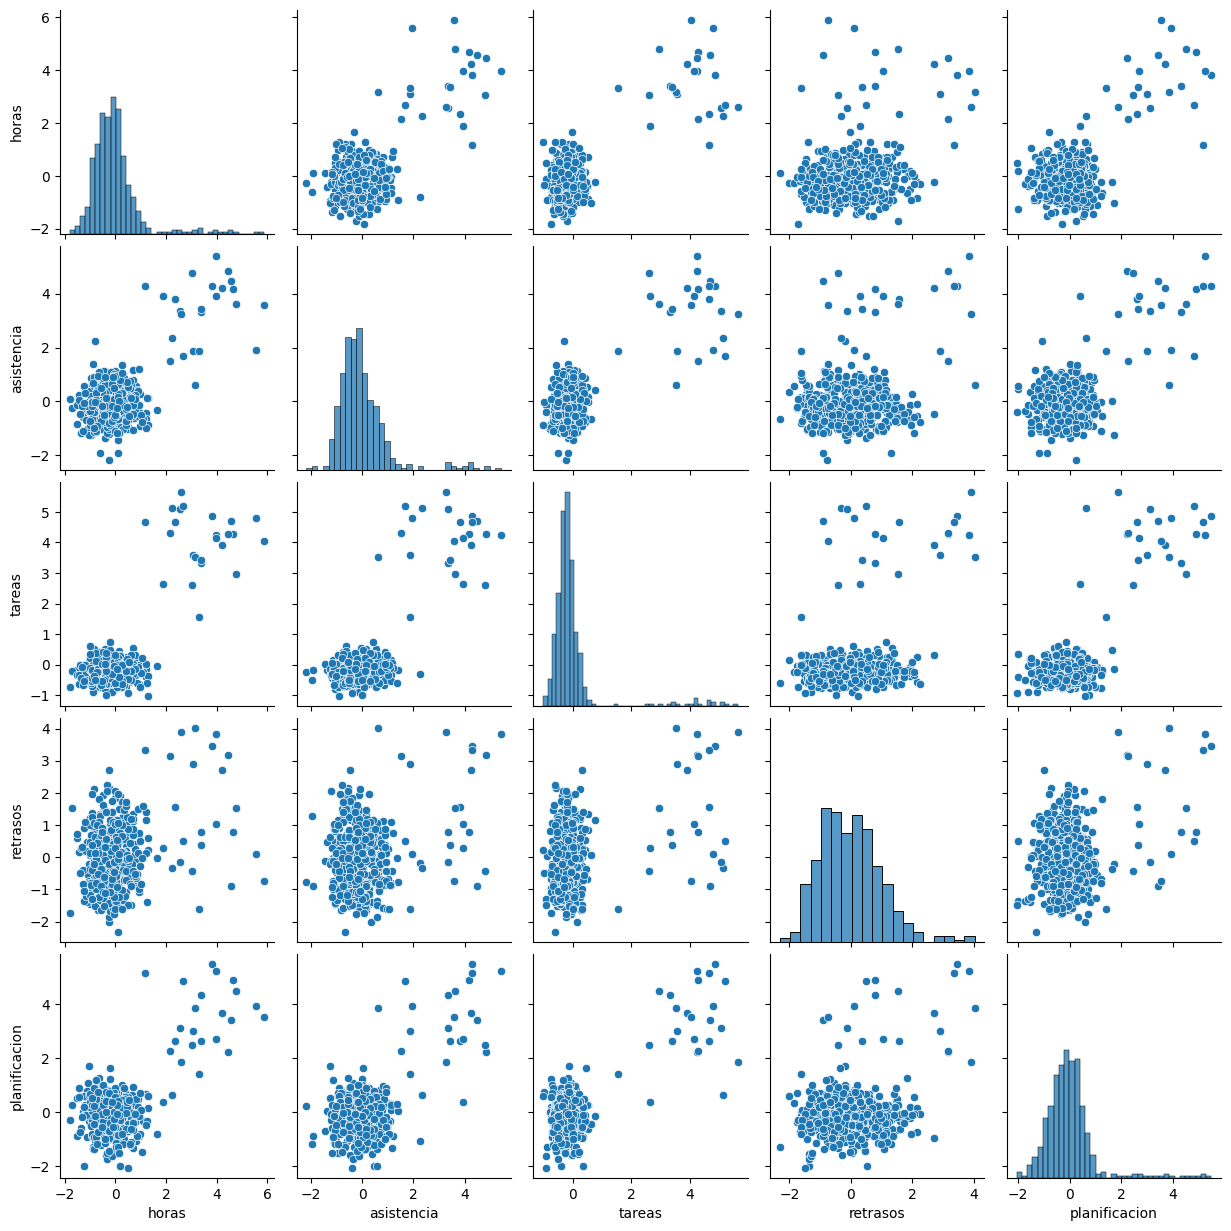


Matriz de correlación:
                  horas  asistencia    tareas  retrasos  planificacion
horas          1.000000    0.628178  0.744915  0.248881       0.599661
asistencia     0.628178    1.000000  0.744944  0.206153       0.585946
tareas         0.744915    0.744944  1.000000  0.336141       0.728063
retrasos       0.248881    0.206153  0.336141  1.000000       0.266693
planificacion  0.599661    0.585946  0.728063  0.266693       1.000000


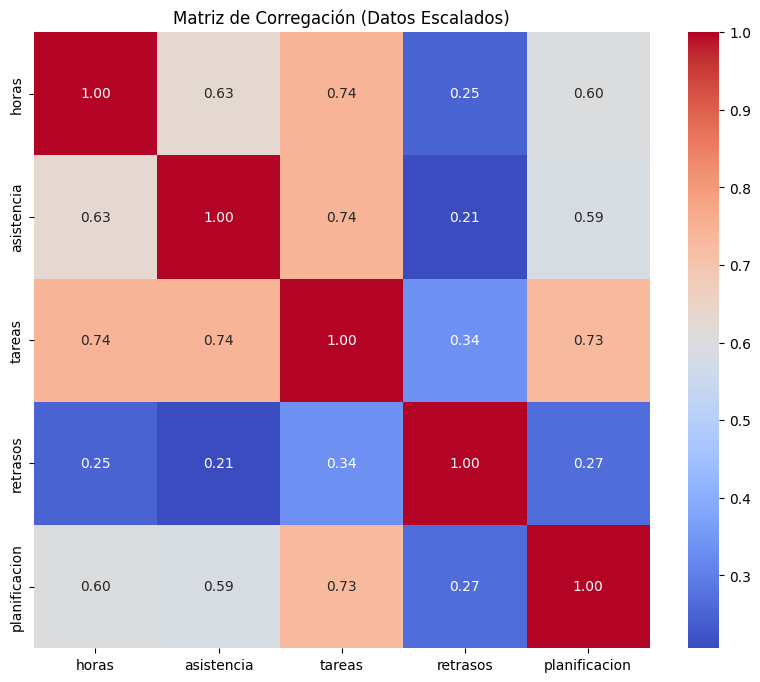

In [32]:
# Resumen estadístico del DataFrame escalado
print("Resumen de scaled_df:")
print(scaled_df.describe())

# Boxplot de las variables escaladas
plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_df)
plt.title("Boxplot de variables escaladas")
plt.show()

# Matriz de dispersión (Scatter plot matrix / pairs)
sns.pairplot(scaled_df)
plt.show()

# Matriz de correlación de los datos escalados
mcor = scaled_df.corr()
print("\nMatriz de correlación:")
print(mcor)

# Visualización de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(mcor, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de Corregación (Datos Escalados)")
plt.show()


Sin embargo, si las escalas son comparables, el escalado puede no ser deseable, como se muestra en el ejemplo siguiente:


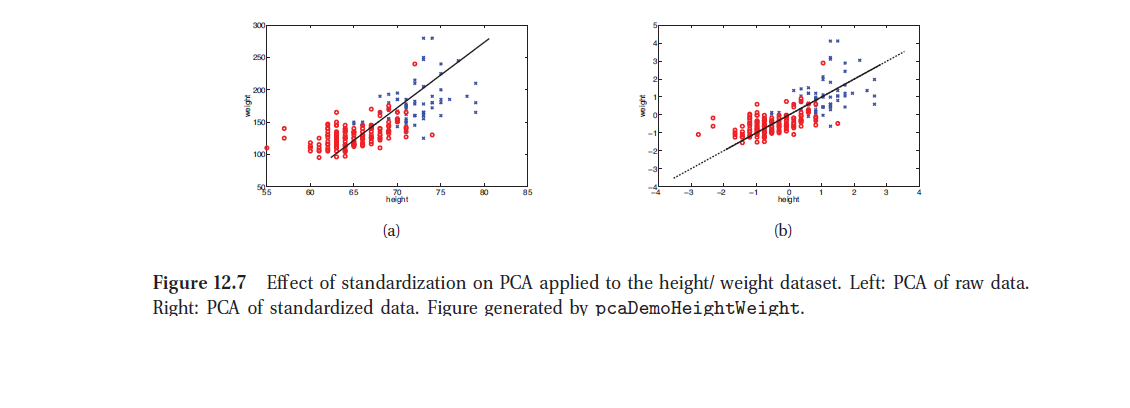

In [35]:
# Mostrar la imagen figura2.png
display(Image(filename="figura2.png"))

In [36]:
# Matriz de covarianzas empírica
mdat_cov = scaled_df.cov()
# Valores y vectores propios
# np.linalg.eig devuelve (valores_propios, vectores_propios)
eigen_values, eigen_vectors = np.linalg.eig(mdat_cov)
# Ordenar de mayor a menor (opcional, pero recomendado para PCA)
idx = eigen_values.argsort()[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]
print("Valores propios:")
print(eigen_values)
print("\nVectores propios (como columnas):")
print(eigen_vectors)
# Para acceder a un objeto similar al de R:
# mdat_eigen = {'values': eigen_values, 'vectors': eigen_vectors}

Valores propios:
[3.15893344 0.87988346 0.41787961 0.37036384 0.18344385]

Vectores propios (como columnas):
[[-0.47683399 -0.13487116 -0.2925464   0.76498437  0.28923111]
 [-0.47084276 -0.21401512 -0.46948092 -0.63529503  0.329382  ]
 [-0.52377868 -0.05623068 -0.0161918  -0.02137716 -0.84957333]
 [-0.24002309  0.96267866 -0.07905984 -0.04295765  0.08684987]
 [-0.46795433 -0.07807183  0.82915115 -0.09432277  0.28024118]]


In [37]:
# Extraer los vectores propios de las dos primeras componentes (primeras dos columnas)
# Multiplicamos por -1 para coincidir con la rotación del ejemplo en R
w = -eigen_vectors[:, 0:2]
# Crear un DataFrame para asignar nombres a las filas y columnas
w_df = pd.DataFrame(w, index=scaled_df.columns, columns=['PC1', 'PC2'])
print("Cargas (pesos) de las dos primeras componentes principales:")
print(w_df)

Cargas (pesos) de las dos primeras componentes principales:
                    PC1       PC2
horas          0.476834  0.134871
asistencia     0.470843  0.214015
tareas         0.523779  0.056231
retrasos       0.240023 -0.962679
planificacion  0.467954  0.078072


In [38]:
# Calcular la proyección de los datos (Puntajes/Scores) 
# Multiplicación matricial: datos_escalados x pesos
PC = scaled_df @ w_df

# Las columnas ya tienen nombre si usamos el DataFrame w_df previo
print("Primeras filas de la proyección (PC1 y PC2):")
print(PC.head())

Primeras filas de la proyección (PC1 y PC2):
        PC1       PC2
0 -0.415146  1.147818
1  0.422252 -1.088267
2  9.801493 -1.200856
3  0.260299 -0.860500
4 -0.029719 -0.775963


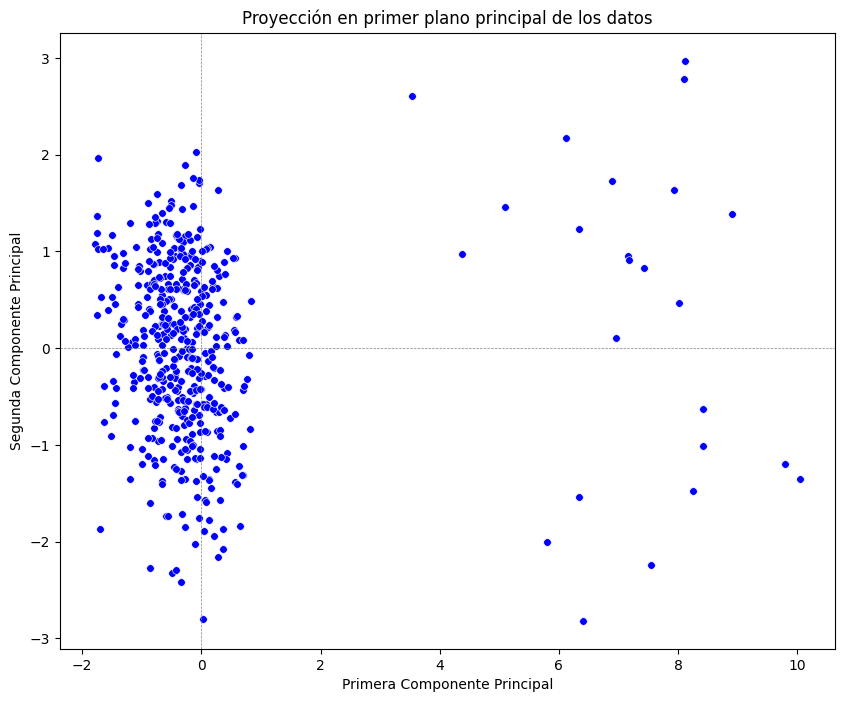

In [39]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Dibujar las líneas de referencia cruzadas (Ejes en 0)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Crear el gráfico de dispersión (Equivalente al geom_text con 'o')
sns.scatterplot(x='PC1', y='PC2', data=PC, marker='o', color='blue', s=30)

# Personalizar etiquetas y título
plt.xlabel("Primera Componente Principal")
plt.ylabel("Segunda Componente Principal")
plt.title("Proyección en primer plano principal de los datos")

# Mostrar el gráfico
plt.show()

In [40]:
# Cálculo de la proporción de varianza explicada (PVE)
# Se divide cada valor propio por la suma total de los valores propios
PVE = eigen_values / np.sum(eigen_values)

# Mostrar la PVE redondeada a 2 decimales
print("Varianza explicada por componente (PVE):")
print(np.round(PVE, 2))

Varianza explicada por componente (PVE):
[0.63 0.18 0.08 0.07 0.04]


La primera componente principal en el ejemplo explica el 63% de la variabilidad, y la segunda componente principal explica el 18%. Juntas, las dos primeras componentes principales explican el 81% de la variabilidad. 

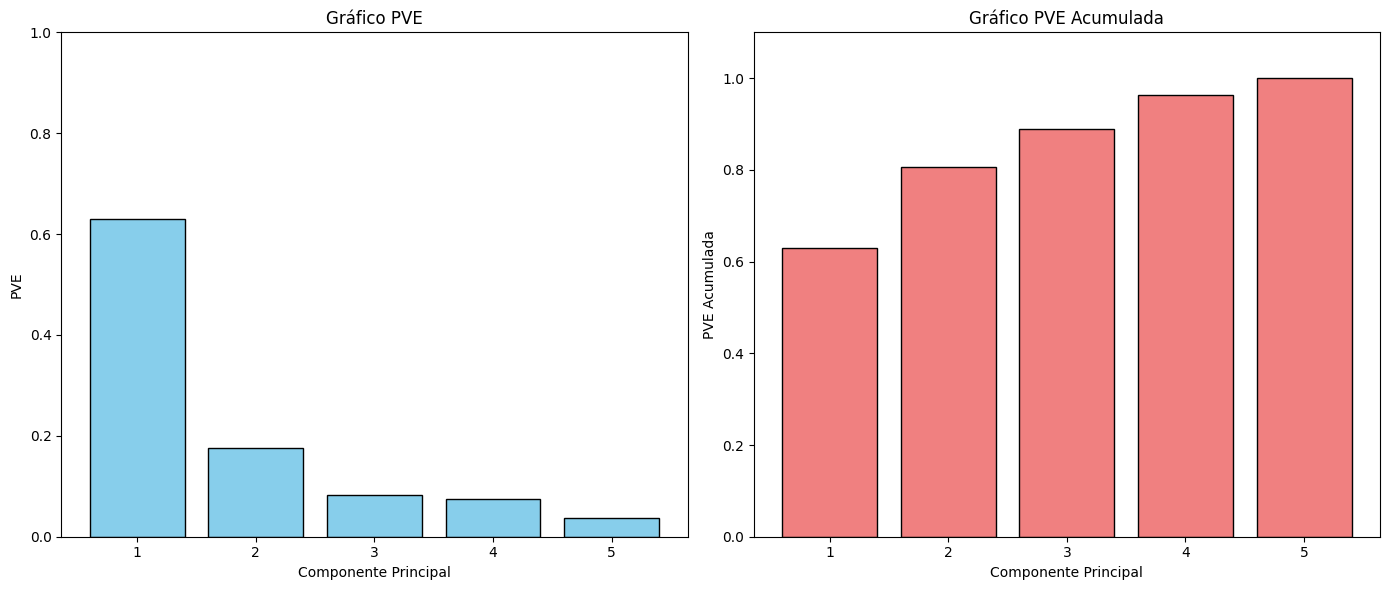

In [41]:
# Configurar el lienzo para tener dos gráficos uno al lado del otro
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de la PVE Individual
ax1.bar(range(1, len(PVE) + 1), PVE, color='skyblue', edgecolor='black')
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("PVE")
ax1.set_title("Gráfico PVE")
ax1.set_ylim(0, 1)
ax1.set_xticks(range(1, len(PVE) + 1))

# 2. Gráfico de la PVE Acumulada
ax2.bar(range(1, len(PVE) + 1), np.cumsum(PVE), color='lightcoral', edgecolor='black')
ax2.set_xlabel("Componente Principal")
ax2.set_ylabel("PVE Acumulada")
ax2.set_title("Gráfico PVE Acumulada")
ax2.set_ylim(0, 1.1) # Un poco más de 1 para visibilidad
ax2.set_xticks(range(1, len(PVE) + 1))

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

## Ahora con las funciones predefinidas en R

In [ ]:
# 1. Escalar los datos (equivalente a scale = TRUE en prcomp)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(datos)

# 2. Ejecutar PCA
pca = PCA()
pca_x = pca.fit_transform(scaled_data)

# 3. Mapeo de atributos de prcomp a scikit-learn:

# sdev (desviaciones estándar de los componentes principales)
sdev = np.sqrt(pca.explained_variance_)

# rotation (matriz de carga/loadings). Multiplicamos por -1 para coincidir con el ejemplo en R
rotation = -pca.components_.T

# center (medias originales)
center = scaler.mean_

# scale (desviaciones estándar originales)
scale = scaler.scale_

# x (las coordenadas proyectadas / scores). Multiplicamos por -1 por consistencia
x = -pca_x

# Mostrar resultados
print("Desviaciones estándar (sdev):")
print(sdev)

print("\nMatriz de rotación (rotation/loadings):")
print(rotation)

print("\nCoordenadas proyectadas (x - primeros 5):")
print(x[:5])

Desviaciones estándar (sdev):
[1.77733886 0.93802103 0.64643609 0.60857526 0.42830346]

Matriz de rotación (rotation/loadings):
[[-0.47683399  0.13487116  0.2925464  -0.76498437  0.28923111]
 [-0.47084276  0.21401512  0.46948092  0.63529503  0.329382  ]
 [-0.52377868  0.05623068  0.0161918   0.02137716 -0.84957333]
 [-0.24002309 -0.96267866  0.07905984  0.04295765  0.08684987]
 [-0.46795433  0.07807183 -0.82915115  0.09432277  0.28024118]]

Coordenadas proyectadas (x - primeros 5):
[[ 0.41514572  1.14781771 -0.34706926 -0.10938634  0.30220833]
 [-0.42225245 -1.08826655  0.52704695 -1.18442389  0.33561566]
 [-9.80149268 -1.20085642 -1.07890119  0.56317161  0.21672696]
 [-0.26029913 -0.86049995 -0.33238161  0.82476034 -0.48008219]
 [ 0.02971892 -0.77596295 -0.81032404  0.11962238 -0.45448188]]


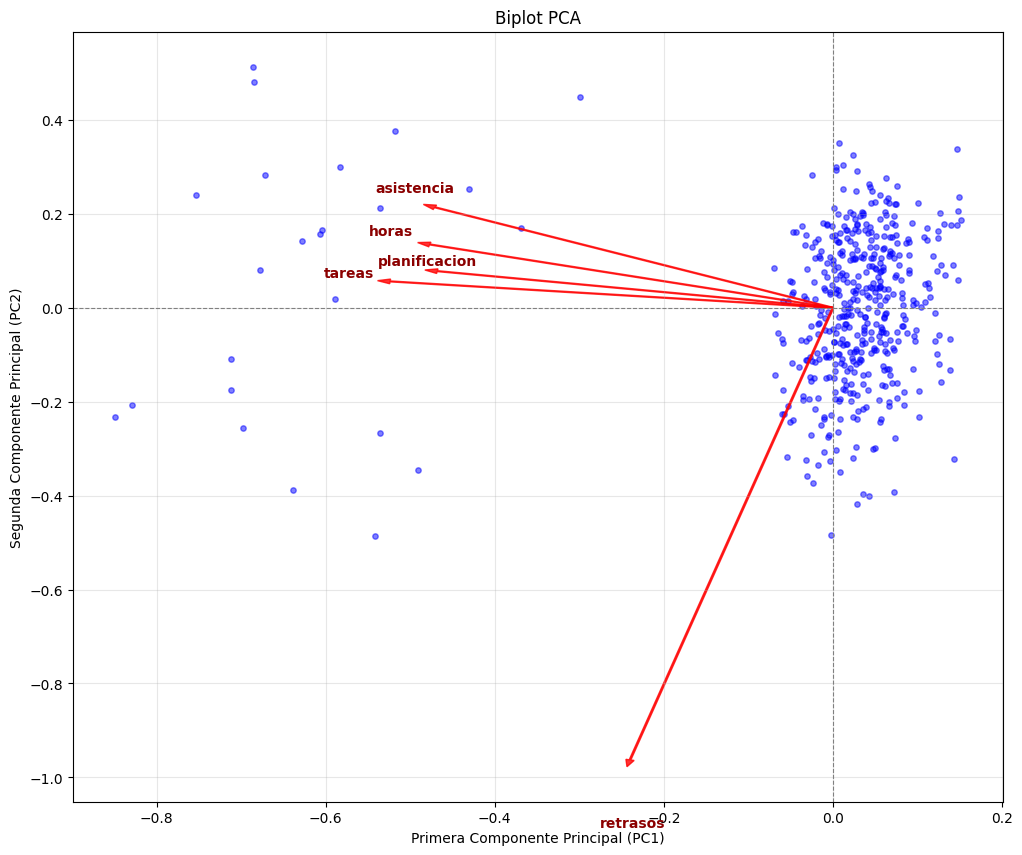

In [43]:
def biplot(score, coeff, labels=None):
    """
    Función para crear un gráfico biplot en Python.
    :param score: Coordenadas proyectadas de los datos (PCA x)
    :param coeff: Matriz de carga (PCA components / rotation)
    :param labels: Nombres de las variables
    """
    # Proyección de las muestras (PC1 y PC2)
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    
    # Factor de escala para que las muestras y los vectores compartan el mismo espacio visual
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    
    plt.figure(figsize=(12, 10))
    
    # Graficar las muestras (equivalente a xlabs='o')
    plt.scatter(xs * scalex, ys * scaley, c='blue', s=15, alpha=0.5)
    
    # Graficar los vectores de carga (flechas)
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='red', alpha=0.8, width=0.002, head_width=0.01)
        if labels is None:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, "Var" + str(i + 1), color='darkred')
        else:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, labels[i], color='darkred', weight='bold')

    plt.xlabel("Primera Componente Principal (PC1)")
    plt.ylabel("Segunda Componente Principal (PC2)")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.title("Biplot PCA")
    plt.grid(alpha=0.3)
    plt.show()

# Usar la función con los resultados de scikit-learn generados antes
# score = x (scores proyectados)
# coeff = rotation (matriz de carga / components transpuesta)
biplot(x, rotation, labels=datos.columns)

#### Ejercicio 1
1. Explique como se obtienen las coordenadas de  variables y observaciones en el gráfico biplot y como se interpreta la representación obtenida.
2. Compare los resultados obtenidos utilizando la función predefinida en R prcomp con aquellos de los cálculos previos. Explique a que corresponden cada una de las componente del objeto resultante de utilizar la función prcomp. 

#### Ejercicio 2:
Considere los datos asignados a su grupo. Extraiga para análisis todos los datos salvo la última y penúltimas columnas. 
Se trata de realizar un análisis exploratorio de estos datos incluyendo un PCA. 
1. Realice un análisis exploratorio de los datos de las características de sus datos, incluyendo resúmenes de cada variable, boxplots, correlaciones y análisis de componentes principales (PCA).
2. Interprete sus resultados en (i). Indique cual es el interés de utilizar PCA en este conjunto de datos y si se sugiere algún tipo de limpieza de datos a partir del análisis realizado.